# Connect to Google Account

In [1]:
from google.colab import drive
drive.mount('/content/data', force_remount=True)

Mounted at /content/data


# import

In [2]:
!pip install -q catboost xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [3]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import random
import torch

# 데이터 시각화에 사용할 라이브러리
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
from sklearn.inspection import permutation_importance
from catboost import CatBoostClassifier
#from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


In [4]:
# 브라우저에서 바로 그려지도록
%matplotlib inline

# 유니코드에서  음수 부호설정
mpl.rc('axes', unicode_minus=False)

# 실험저장 로그

In [5]:
def save_experiment_log(
    model_name,
    feature_version,
    feature_count,
    result_obj,
    save_dir="results",
    public_score=None,
    notes="",
    params=None
):
    os.makedirs(save_dir, exist_ok=True)

    log_path = os.path.join(save_dir, "experiment_log.csv")
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_id = f"{model_name}_{feature_version}_{timestamp}"

    summary_df = result_obj["summary_df"].copy()
    row = summary_df.iloc[0].to_dict()

    log_row = {
        "exp_id": exp_id,
        "timestamp": timestamp,
        "model": model_name,
        "feature_version": feature_version,
        "feature_count": feature_count,
        "best_threshold": row.get("best_threshold"),
        "f1": row.get("f1"),
        "precision": row.get("precision"),
        "recall": row.get("recall"),
        "accuracy": row.get("accuracy"),
        "auc": row.get("auc"),
        "cv_f1_mean": row.get("cv_f1_mean"),
        "cv_f1_std": row.get("cv_f1_std"),
        "cv_auc_mean": row.get("cv_auc_mean"),
        "cv_auc_std": row.get("cv_auc_std"),
        "public_score": public_score,
        "notes": notes,
        "submission_path": result_obj.get("submission_path", ""),
    }

    if params is not None:
        log_row["params"] = json.dumps(params, ensure_ascii=False)
    else:
        log_row["params"] = ""

    if os.path.exists(log_path):
        old_log = pd.read_csv(log_path)
        new_log = pd.concat([old_log, pd.DataFrame([log_row])], ignore_index=True)
    else:
        new_log = pd.DataFrame([log_row])

    new_log.to_csv(log_path, index=False, encoding="utf-8-sig")

    print(f"실험 로그 저장 완료: {log_path}")
    print(f"exp_id: {exp_id}")

    return exp_id, new_log

# 가장 좋은 실험만 정렬해서 보는 함수

In [6]:
def show_experiment_leaderboard(save_dir="results", sort_by="public_score", ascending=False):
    log_path = os.path.join(save_dir, "experiment_log.csv")

    if not os.path.exists(log_path):
        raise FileNotFoundError(f"로그 파일이 없음: {log_path}")

    log_df = pd.read_csv(log_path)

    if sort_by not in log_df.columns:
        raise ValueError(f"정렬 기준 컬럼이 없음: {sort_by}")

    display_cols = [
        "exp_id", "model", "feature_version", "feature_count",
        "best_threshold", "f1", "auc", "cv_f1_mean", "cv_auc_mean",
        "public_score", "notes"
    ]

    result_df = log_df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    return result_df[display_cols]

#public score 나중에 업데이트하는 함수

In [7]:
def update_public_score(
    exp_id,
    public_score,
    save_dir="results"
):
    log_path = os.path.join(save_dir, "experiment_log.csv")

    if not os.path.exists(log_path):
        raise FileNotFoundError(f"로그 파일이 없음: {log_path}")

    log_df = pd.read_csv(log_path)

    if exp_id not in log_df["exp_id"].values:
        raise ValueError(f"해당 exp_id를 찾을 수 없음: {exp_id}")

    log_df.loc[log_df["exp_id"] == exp_id, "public_score"] = public_score
    log_df.to_csv(log_path, index=False, encoding="utf-8-sig")

    print(f"public_score 업데이트 완료: {exp_id} -> {public_score}")
    return log_df

# Global Variables

In [8]:
def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)      # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed)                       # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed)                  # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True     # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


In [9]:
import easydict
args = easydict.EasyDict()

reset_seeds() # 랜덤 고정!!

# path 정보
args.default_path = '/content/data/MyDrive/kaggle/data/'
args.train_csv = args.default_path+'train.csv'
args.test_csv = args.default_path+'test.csv'
args.default_submission_csv = args.default_path+'submission.csv'

# 제출할 파일 이름 양식 = _날짜_순
args.submission_path = '/content/data/MyDrive/kaggle/submission/'
args.submission_csv = 'submission.csv'
args.save_results = "model_results.json"

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

# Load Titanic


- Surived:0=사망, 1=생존
- Pclass: 1=1등석, 2=2등석, 3=3등석
- gender:male=남성, female=여성
- Age: 나이
- SibSp: 타이타닉 호에 동승한 자매/배우자의 수
- Parch: 타이타닉 호에 동승한 부모/자식의 수
- Ticket: 티켓 번호
- Fare: 승객 요금
- Cabin: 방 호수
- Embarked: 탑승지; C=셰르부르, Q=퀴즈타운, S=사우샘프턴

In [10]:
plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [11]:
ori_train = pd.read_csv(args.train_csv)
ori_test = pd.read_csv(args.test_csv)

# traindataset => feature+target
# test dataset => features + target은 없음 (예측해야함)
ori_train.shape, ori_test.shape

((916, 12), (393, 11))

In [12]:
pd.read_csv(args.default_submission_csv).shape

(393, 2)

In [13]:
ori_train.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [14]:
ori_train['passengerid'].nunique(), ori_train.shape[0]

(916, 916)

In [15]:
ori_train.drop('passengerid', axis=1, inplace=True)
ori_train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


In [16]:
ori_test.set_index(['passengerid'], inplace=True)
print(f'{ori_test.shape}')
ori_test.head()

(393, 10)


,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,
916,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
917,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S
918,3,"McCarthy, Miss. Catherine Katie""""",female,NaN,0,0,383123,7.7500,NaN,Q
919,3,"Franklin, Mr. Charles (Charles Fardon)",male,NaN,0,0,SOTON/O.Q. 3101314,7.2500,NaN,S
920,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S


# train_test_split

In [17]:
new_survived = pd.Categorical(ori_train["survived"])
new_survived = new_survived.rename_categories(["Died","Survived"])

new_survived.describe()

,counts,freqs
categories,,
Died,570,0.622271
Survived,346,0.377729


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
y = ori_train['survived']
X = ori_train.drop(['survived'], axis=1)

In [20]:
reset_seeds()
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=ori_train['survived'])
# 테스트 사이즈 축소

X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((641, 10), (275, 10), (641,), (275,))

# Data Preprocessing

In [21]:
train = X_tr.copy()       # 학습용 데이터셋 (features+target)
test = X_te.copy()        # 평가용 데이터셋 (features+target)
ori_te = ori_test.copy()  # 제출용 데이터셋 (features)

In [22]:
import pandas as pd
import numpy as np

# -----------------------------------
# 1. train 기준 전처리 규칙 학습
# -----------------------------------
def fit_preprocess_rules(train: pd.DataFrame) -> dict:
    train = train.copy()

    # 기본 name 파생
    train["family_name"] = train["name"].str.split(",").str[0].str.strip()
    train["title"] = train["name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

    train["title"] = train["title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    rare_title_map = {
        "Lady": "Noble",
        "Countess": "Noble",
        "Sir": "Noble",
        "Dona": "Noble",
        "Don": "Noble",
        "Jonkheer": "Noble",
        "Capt": "Officer",
        "Col": "Officer",
        "Major": "Officer",
        "Dr": "Professional",
        "Rev": "Professional"
    }

    train["title_group"] = train["title"].replace(rare_title_map)

    # age 규칙
    family_age_median = train.groupby("family_name")["age"].median().to_dict()
    family_count = train.groupby("family_name")["family_name"].count().to_dict()
    pg_age_median = train.groupby(["pclass", "gender"])["age"].median().to_dict()
    global_age_median = train["age"].median()

    # fare 규칙
    fare_median = train["fare"].median()
    train_fare_filled = train["fare"].fillna(fare_median)

    _, fare_bins = pd.qcut(
        train_fare_filled,
        q=4,
        labels=["low", "mid", "high", "very_high"],
        retbins=True,
        duplicates="drop"
    )

    fare_bins = np.array(fare_bins, dtype=float)
    fare_bins[0] = -np.inf
    fare_bins[-1] = np.inf

    rules = {
        "rare_title_map": rare_title_map,
        "family_age_median": family_age_median,
        "family_count": family_count,
        "pg_age_median": pg_age_median,
        "global_age_median": global_age_median,
        "fare_median": fare_median,
        "fare_bins": fare_bins,
        "fare_labels": ["low", "mid", "high", "very_high"]
    }

    return rules


# -----------------------------------
# 2. age 채우기 함수
# -----------------------------------
def fill_age(row, rules):
    if pd.notnull(row["age"]):
        return row["age"]

    fam = row["family_name"]

    # 1) family_name 기준
    if rules["family_count"].get(fam, 0) >= 2:
        fam_med = rules["family_age_median"].get(fam, np.nan)
        if pd.notnull(fam_med):
            return fam_med

    # 2) pclass + gender 기준
    key = (row["pclass"], row["gender"])
    pg_med = rules["pg_age_median"].get(key, np.nan)
    if pd.notnull(pg_med):
        return pg_med

    # 3) 전체 median
    return rules["global_age_median"]


# -----------------------------------
# 3. feature 생성
# -----------------------------------
def add_hypothesis_features(df: pd.DataFrame, rules: dict) -> pd.DataFrame:
    df = df.copy()

    rare_title_map = rules["rare_title_map"]
    fare_median = rules["fare_median"]
    fare_bins = rules["fare_bins"]
    fare_labels = rules["fare_labels"]

    # 1. 기본 name 파생
    df["family_name"] = df["name"].str.split(",").str[0].str.strip()
    df["title"] = df["name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()

    df["title"] = df["title"].replace({
        "Mlle": "Miss",
        "Ms": "Miss",
        "Mme": "Mrs"
    })

    df["title_group"] = df["title"].replace(rare_title_map)

    # 2. 가족 관련
    df["family_size"] = df["sibsp"] + df["parch"] + 1
    df["is_alone"] = (df["family_size"] == 1).astype(int)

    def family_size_group(x):
        if x == 1:
            return "alone"
        elif 2 <= x <= 4:
            return "small"
        else:
            return "large"

    df["family_size_group"] = df["family_size"].apply(family_size_group)

    # 3. age 결측치 처리
    df["age"] = df.apply(lambda r: fill_age(r, rules), axis=1)

    # 4. 성별 관련
    df["is_female"] = (df["gender"] == "female").astype(int)
    df["is_male"] = (df["gender"] == "male").astype(int)

    # 5. 선상 접근성 / 위치 근사

    df["deck"] = df["cabin"].fillna("Unknown").astype(str).apply(
    lambda x: x[0] if x != "Unknown" else "Unknown"
    )

    df["has_cabin"] = df["cabin"].notnull().astype(int)

    df["upper_access"] = 0
    df.loc[df["pclass"] == 1, "upper_access"] = 2
    df.loc[df["pclass"] == 2, "upper_access"] = 1
    df.loc[df["pclass"] == 3, "upper_access"] = 0

    df["access_score"] = df["upper_access"] + df["has_cabin"]

    # 6. age / fare 구간화
    df["age_bin"] = pd.cut(
        df["age"],
        bins=[0,5,10,15,20,25, 30,35,40,45, 50,55,60,65,70,75,80,85,90],
        labels=False,
        include_lowest=True
    )

    df["fare"] = df["fare"].fillna(fare_median)

    df["fare_bin"] = pd.cut(
        df["fare"],
        bins=fare_bins,
        labels=fare_labels,
        include_lowest=True
    )

    def family_survival_zone(size):
        if size == 1:
            return "alone"
        elif 2 <= size <= 4:
            return "small"
        elif 5 <= size <= 7:
            return "medium"
        else:
            return "large"


    # 7. 조합 feature 0311
    df["is_child"] = (df["age"] < 16).astype(int)
    df["male_child"] = ((df["gender"] == "male") & (df["age"] < 16)).astype(int)
    df["female_child"] = ((df["gender"] == "female") & (df["age"] < 16)).astype(int)
    df["pclass_gender_has_cabin"] = ((df["is_female"] == 1) & (df["has_cabin"] == 0) & (df["pclass"] == 3)).astype(int) #0311
    df["child_with_family"] = ((df["age"] < 16) & (df["family_size"] > 1)).astype(int)
    df["fare_per_person"] = (df["fare"] / np.maximum(df["family_size"], 1)).astype(float)

    #######################################################################
    df["pclass_gender"] = df["pclass"].astype(str) + "_" + df["gender"].astype(str)            #0313
    df["pclass_title"] = df["pclass"].astype(str) + "_" + df["title_group"].astype(str)
    df["pclass_age_bin"] = df["pclass"].astype(str) + "_" + df["age_bin"].astype(str)
    df["pclass_is_male"] = df["pclass"].astype(str) + "_" + df["is_male"].astype(str)
    df["pclass_is_alone"] = df["pclass"].astype(str) + "_" + df["is_alone"].astype(str)
    df["access_pclass"] = df["access_score"].astype(str) + "_" + df["pclass"].astype(str)
    df["gender_title_group"] = df["gender"].astype(str) + "_" + df["title_group"].astype(str)        #0313
    df["gender_age_bin"] = df["gender"].astype(str) + "_" + df["age_bin"].astype(str)                #0313
    df["has_cabin_gender"] = df["has_cabin"].astype(str) + "_" + df["gender"].astype(str)                       #0311
    #df["ticket_farebin"] = df["ticket"].astype(str) + "_" + df["fare_bin"].astype(str)                          #0311
    df["family_survival_zone"] = df["family_size"].apply(family_survival_zone)
    df["female_child_pclass"] = df["female_child"].astype(str) + "_" + df["pclass"].astype(str)
    df["female_age_bin"] = df["is_female"].astype(str) + "_" + df["age_bin"].astype(str)
    df["female_familysize"] = df["is_female"].astype(str) + "_" + df["family_size"].astype(str)                #실험1
    df["male_familysize"] = df["is_male"].astype(str) + "_" + df["family_size"].astype(str)                    #실험1
    df["pclass_farebin"] = df["pclass"].astype(str) + "_" + df["fare_bin"].astype(str)
    #df["ticket_farebin_gender"] = df["gender"].astype(str) + "_" + df["ticket_farebin"].astype(str)
    df["gender_farebin"] =  df["gender"].astype(str) + "_" + df["fare_bin"].astype(str)
    #df["cabin_fare_bin"] = df["cabin"].astype(str) + "_" + df["fare_bin"].astype(str)                          #실험1
    #df["cabin_fare_bin_family_size"] = df["cabin_fare_bin"].astype(str) + "_" + df["family_size"].astype(str)
    #df["fare_bin_familysize"] = df["fare_bin"].astype(str) + "_" + df["family_size"].astype(str)
    df["pclass_gender_has_cabin"] = df["pclass_gender"].astype(str) + "_" + df["has_cabin"].astype(str)        #0311

    ####################################################################

    #df["surname"] = df["name"].str.split(",").str[0]
    #surname_survival = df.groupby("surname")["survived"].mean()
    #df["surname_survival_rate"] = df["surname"].map(surname_survival)


    ticket_counts = df.groupby("ticket")["ticket"].transform("count")

    df["ticket_group_size"] = ticket_counts

    df["ticket_group_size_bin"] = pd.cut(
        df["ticket_group_size"],
        bins=[0,1,2,4,10],
        labels=["solo","pair","small","large"]
    )

    ticket_count = df["ticket"].value_counts()

    df["ticket_group"] = df["ticket"].map(ticket_count)
    df["ticket_group"] = df["ticket_group"].apply(lambda x: 1 if x == 1 else 0)

    df["ticket_group_farebin"] = df["ticket_group"].astype(str) + "_" + df["fare_bin"].astype(str)


    return df

# EDA 분석 피쳐보기

In [23]:
# 1. train 기준 규칙 생성
rules = fit_preprocess_rules(train)

# 2. train / test / ori_te 모두 같은 규칙 적용
train = add_hypothesis_features(train, rules)
test = add_hypothesis_features(test, rules)
ori_te = add_hypothesis_features(ori_te, rules)

# 3. 확인
train.isnull().sum().sum(), test.isnull().sum().sum(), ori_te.isnull().sum().sum(),

(np.int64(503), np.int64(216), np.int64(297))

In [24]:
train.shape

(641, 50)

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 641 entries, 539 to 636
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   pclass                   641 non-null    int64   
 1   name                     641 non-null    object  
 2   gender                   641 non-null    object  
 3   age                      641 non-null    float64 
 4   sibsp                    641 non-null    int64   
 5   parch                    641 non-null    int64   
 6   ticket                   641 non-null    object  
 7   fare                     641 non-null    float64 
 8   cabin                    138 non-null    object  
 9   embarked                 641 non-null    object  
 10  family_name              641 non-null    object  
 11  title                    641 non-null    object  
 12  title_group              641 non-null    object  
 13  family_size              641 non-null    int64   
 14  is_alone     

In [26]:
drop_cols = ["name",
             "ticket",
             "cabin",
             "family_name",
             "is_male",
             "is_alone" ,
             "family_size_group",
             "ticket_group_size_bin",
             "ticket_group",
             "gender",
             "pclass_is_male",
             "pclass_is_alone",
             "has_cabin",
             "sibsp" ,
             "parch" ,
             "fare_bin",
             "is_child" ,
             "male_child" ,
             "female_child" ,
             "pclass_gender_has_cabin",
             "child_with_family" ,
             "pclass_gender" ,
             "pclass_title" ,
             "pclass_age_bin" ,
             "access_pclass",
             "gender_title_group" ,
             "gender_age_bin",
             "has_cabin_gender" ,
             "female_child_pclass",
             "female_age_bin" ,
             "female_familysize",
             "male_familysize",
             "pclass_farebin",
             "gender_farebin" ,
             "ticket_group_farebin"
             ]
#  is_male , upper_access, access_pclass, child_with_family, family_survival_zone, ticket_group, gender, pclass_is_male, has_cabin
train = train.drop(columns=[c for c in drop_cols if c in train.columns])
test = test.drop(columns=[c for c in drop_cols if c in test.columns])
ori_te = ori_te.drop(columns=[c for c in drop_cols if c in ori_te.columns])

In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 641 entries, 539 to 636
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pclass                641 non-null    int64  
 1   age                   641 non-null    float64
 2   fare                  641 non-null    float64
 3   embarked              641 non-null    object 
 4   title                 641 non-null    object 
 5   title_group           641 non-null    object 
 6   family_size           641 non-null    int64  
 7   is_female             641 non-null    int64  
 8   deck                  641 non-null    object 
 9   upper_access          641 non-null    int64  
 10  access_score          641 non-null    int64  
 11  age_bin               641 non-null    int64  
 12  fare_per_person       641 non-null    float64
 13  family_survival_zone  641 non-null    object 
 14  ticket_group_size     641 non-null    int64  
dtypes: float64(3), int64(7), o

# 컬럼 정의 함수

In [28]:
def get_feature_groups(df: pd.DataFrame):
    numeric_cols = [
        "age", "fare",
        "family_size",
        "is_female",
        "upper_access",
        "access_score",
        "fare_per_person"
    ]
    # 드롭대상 : "is_male", "is_alone", "ticket_group", "has_cabin",

    categorical_cols = [
        "pclass",  "embarked", "title", "title_group", "family_survival_zone", "deck", "age_bin", "ticket_group_size"
    ]
    # 드롭 대상 family_size_group "ticket_group_size_bin","gender", "pclass_is_male",  "pclass_is_alone",

    numeric_cols = [c for c in numeric_cols if c in df.columns]
    categorical_cols = [c for c in categorical_cols if c in df.columns]

    return numeric_cols, categorical_cols

# 데이터프레임 정리

In [29]:
def prepare_frame(df: pd.DataFrame, numeric_cols: list, categorical_cols: list):
    df = df.copy()

    if "deck" in df.columns:
        df["deck"] = df["deck"].astype("object").fillna("Unknown")

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype("object").fillna("Unknown").astype(str)

    for col in numeric_cols:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())

    return df

# 전처리기 생성 함수

In [30]:
def build_preprocessor(numeric_cols: list, categorical_cols: list):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ],
        remainder="drop"
    )
    return preprocessor

In [31]:
train.shape, test.shape, ori_te.shape

((641, 15), (275, 15), (393, 15))

In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 641 entries, 539 to 636
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   pclass                641 non-null    int64  
 1   age                   641 non-null    float64
 2   fare                  641 non-null    float64
 3   embarked              641 non-null    object 
 4   title                 641 non-null    object 
 5   title_group           641 non-null    object 
 6   family_size           641 non-null    int64  
 7   is_female             641 non-null    int64  
 8   deck                  641 non-null    object 
 9   upper_access          641 non-null    int64  
 10  access_score          641 non-null    int64  
 11  age_bin               641 non-null    int64  
 12  fare_per_person       641 non-null    float64
 13  family_survival_zone  641 non-null    object 
 14  ticket_group_size     641 non-null    int64  
dtypes: float64(3), int64(7), o

# Training

In [33]:
reset_seeds()

# threshold 탐색 함수

In [34]:
def find_best_threshold(y_true, probas, metric="f1", start=0.30, end=0.70, step=0.01):
    best_th = 0.5
    best_score = -1

    for th in np.arange(start, end + step, step):
        pred = (probas >= th).astype(int)

        if metric == "f1":
            score = f1_score(y_true, pred)
        elif metric == "accuracy":
            score = accuracy_score(y_true, pred)
        else:
            raise ValueError("metric은 'f1' 또는 'accuracy'만 가능")

        if score > best_score:
            best_score = score
            best_th = th

    return round(float(best_th), 2), float(best_score)

# 평가 지표 함수

In [35]:
def evaluate_predictions(y_true, probas, threshold=0.5):
    pred = (probas >= threshold).astype(int)

    return {
        "threshold": threshold,
        "f1": f1_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "accuracy": accuracy_score(y_true, pred),
        "auc": roc_auc_score(y_true, probas)
    }

# Base model OOF 생성 함수

In [36]:
def generate_single_boosting_oof_predictions(
    model,
    X,
    y,
    X_test,
    preprocessor,
    n_splits=5,
    random_state=42
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))

    fold_f1 = []
    fold_auc = []

    last_model = None
    last_X_valid_enc = None
    last_y_valid = None
    last_feature_names = None

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx].copy()
        y_valid = y.iloc[valid_idx].copy()

        X_train_enc = preprocessor.fit_transform(X_train)
        X_valid_enc = preprocessor.transform(X_valid)
        X_test_enc = preprocessor.transform(X_test)

        clf = model
        clf.fit(X_train_enc, y_train)

        valid_proba = clf.predict_proba(X_valid_enc)[:, 1]
        test_fold_proba = clf.predict_proba(X_test_enc)[:, 1]

        oof_pred[valid_idx] = valid_proba
        test_pred += test_fold_proba / n_splits

        fold_best_th, _ = find_best_threshold(y_valid, valid_proba, metric="f1")
        fold_eval = evaluate_predictions(y_valid, valid_proba, threshold=fold_best_th)

        fold_f1.append(fold_eval["f1"])
        fold_auc.append(fold_eval["auc"])

        print(
            f"Fold {fold} | "
            f"F1: {fold_eval['f1']:.5f} | "
            f"AUC: {fold_eval['auc']:.5f} | "
            f"TH: {fold_best_th:.2f}"
        )

        last_model = clf
        last_X_valid_enc = X_valid_enc
        last_y_valid = y_valid
        last_feature_names = preprocessor.get_feature_names_out()

    return {
        "oof_pred": oof_pred,
        "test_pred": test_pred,
        "fold_f1": fold_f1,
        "fold_auc": fold_auc,
        "last_model": last_model,
        "last_X_valid_enc": last_X_valid_enc,
        "last_y_valid": last_y_valid,
        "last_feature_names": last_feature_names
    }

# Base model 요약 함수

In [37]:
def summarize_base_models(y, oof_base, fold_metrics):
    rows = []

    for name, probas in oof_base.items():
        best_th, _ = find_best_threshold(y, probas, metric="f1")
        result = evaluate_predictions(y, probas, threshold=best_th)

        rows.append({
            "model": name,
            "best_threshold": best_th,
            "f1": result["f1"],
            "precision": result["precision"],
            "recall": result["recall"],
            "accuracy": result["accuracy"],
            "auc": result["auc"],
            "cv_mean_fold_f1@0.5": np.mean(fold_metrics[name]["f1"]),
            "cv_std_fold_f1@0.5": np.std(fold_metrics[name]["f1"]),
            "cv_mean_fold_auc": np.mean(fold_metrics[name]["auc"]),
            "cv_std_fold_auc": np.std(fold_metrics[name]["auc"]),
        })

    summary_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    return summary_df


# confusion matrix 함수


In [38]:
def plot_confusion_matrix_figure(y_true, probas, threshold, save_path=None):
    pred = (probas >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix (th={threshold})")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# ROC curve 함수

In [39]:
def plot_roc_curve_figure(y_true, probas, save_path=None):
    fpr, tpr, _ = roc_curve(y_true, probas)
    auc_score = roc_auc_score(y_true, probas)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# 모델별 AUC 비교 그래프 함수

In [40]:
def plot_model_auc_comparison(y_true, model_proba_dict, save_path=None):
    rows = []
    for name, probas in model_proba_dict.items():
        auc_score = roc_auc_score(y_true, probas)
        rows.append({"model": name, "auc": auc_score})

    auc_df = pd.DataFrame(rows).sort_values("auc", ascending=False)

    plt.figure(figsize=(7, 4))
    plt.bar(auc_df["model"], auc_df["auc"])
    plt.ylabel("AUC")
    plt.title("Model AUC Comparison")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return auc_df

# feature importance 함수(LGBM 직접 / 나머지 permutation)

In [41]:
def get_model_feature_importance(
    model,
    X_valid_enc,
    y_valid,
    feature_names,
    model_name="model",
    n_repeats=5
):
    # 1) tree 계열 / boosting 계열: feature_importances_
    if hasattr(model, "feature_importances_"):
        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_
        }).sort_values("importance", ascending=False).reset_index(drop=True)
        return imp

    # 2) 선형 모델: coef_
    if hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim > 1:
            coef = coef[0]

        imp = pd.DataFrame({
            "feature": feature_names,
            "importance": np.abs(coef)
        }).sort_values("importance", ascending=False).reset_index(drop=True)
        return imp

    # 3) 그 외 모델: permutation importance
    perm = permutation_importance(
        model,
        X_valid_enc,
        y_valid,
        scoring="f1",
        n_repeats=n_repeats,
        random_state=42
    )

    imp = pd.DataFrame({
        "feature": feature_names,
        "importance": perm.importances_mean
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    return imp


def plot_feature_importance_heatmap(importance_df, top_n=20, title="Feature Importance Heatmap", save_path=None):
    plot_df = importance_df.head(top_n).copy()
    plot_df = plot_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(8, max(6, top_n * 0.35)))
    plt.imshow(plot_df[["importance"]], aspect="auto")
    plt.yticks(range(len(plot_df)), plot_df["feature"])
    plt.xticks([0], ["importance"])
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [42]:
def get_logistic_coef_table(model, feature_names):
    coef = model.coef_
    if coef.ndim > 1:
        coef = coef[0]

    df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return df

# FP/FN 분석 함수

In [43]:
def analyze_fp_fn(X_valid, y_true, probas, threshold, save_dir=None, prefix="meta"):
    pred = (probas >= threshold).astype(int)

    error_df = X_valid.copy()
    error_df["y_true"] = y_true.values if isinstance(y_true, pd.Series) else y_true
    error_df["y_pred"] = pred
    error_df["y_proba"] = probas

    fp_df = error_df[(error_df["y_true"] == 0) & (error_df["y_pred"] == 1)].copy()
    fn_df = error_df[(error_df["y_true"] == 1) & (error_df["y_pred"] == 0)].copy()

    print(f"\n[FP/FN Analysis - {prefix}]")
    print("FP count:", len(fp_df))
    print("FN count:", len(fn_df))

    if save_dir:
        fp_df.to_csv(os.path.join(save_dir, f"{prefix}_fp_cases.csv"), index=False)
        fn_df.to_csv(os.path.join(save_dir, f"{prefix}_fn_cases.csv"), index=False)

    return fp_df, fn_df

# 숫자형 상관관계 heatmap 함수

In [44]:
def plot_numeric_correlation_heatmap(X, save_path=None):
    numeric_df = X.select_dtypes(include=["int64", "float64"]).copy()

    corr = numeric_df.corr()

    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.title("Numeric Feature Correlation Heatmap")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return corr

# 전체 피처 상관관계 heatmap 함수

In [45]:
def plot_all_feature_correlation_heatmap(X, save_path=None):
    X_corr = X.copy()

    for col in X_corr.columns:
        if X_corr[col].dtype == "object":
            X_corr[col] = X_corr[col].astype("category").cat.codes

    corr = X_corr.corr(numeric_only=False)

    plt.figure(figsize=(18, 14))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar()
    plt.title("All Feature Correlation Heatmap")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    return corr

# 결과 저장 함수

In [46]:
def save_result_tables(final_eval_df, auc_df, meta_oof, meta_test_proba, final_test_pred, y, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    final_eval_df.to_csv(os.path.join(save_dir, "stacking_f1_evaluation.csv"), index=False)
    auc_df.to_csv(os.path.join(save_dir, "model_auc_comparison.csv"), index=False)

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "meta_oof": meta_oof
    })
    oof_df.to_csv(os.path.join(save_dir, "meta_oof_predictions.csv"), index=False)

    test_pred_df = pd.DataFrame({
        "meta_test_proba": meta_test_proba,
        "meta_test_pred": final_test_pred
    })
    test_pred_df.to_csv(os.path.join(save_dir, "meta_test_predictions.csv"), index=False)

    submission = pd.DataFrame({
        "passengerid": ori_te.index,      # 테스트 데이터 인덱스
        "survived": final_test_pred
    })
    submission_df = pd.read_csv(args.default_submission_csv)
    submission_df["survived"] = final_test_pred

    assert len(submission_df) == len(final_test_pred), "길이 불일치"
    assert submission_df["survived"].isnull().sum() == 0, "survived에 NaN 존재"
    assert set(submission_df["survived"].unique()).issubset({0, 1}), "survived 값이 0/1 아님"

    submission.to_csv(
        os.path.join(save_dir, "submission_te1.csv"),
        index=False
    )

    print("submission saved :", os.path.join(save_dir, "submission.csv"))

# 실행 함수

In [47]:
def run_single_boosting_pipeline(
    model,
    model_name,
    train_df,
    y,
    test_df,
    save_dir="results_boosting"
):
    os.makedirs(save_dir, exist_ok=True)

    # 1) 컬럼 구분
    numeric_cols, categorical_cols = get_feature_groups(train_df)

    # 2) 데이터 준비
    X = prepare_frame(train_df, numeric_cols, categorical_cols)
    X_test = prepare_frame(test_df, numeric_cols, categorical_cols)

    # 3) 전처리기
    preprocessor = build_preprocessor(numeric_cols, categorical_cols)

    # 4) OOF 예측
    result = generate_single_boosting_oof_predictions(
        model=model,
        X=X,
        y=y,
        X_test=X_test,
        preprocessor=preprocessor,
        n_splits=5,
        random_state=42
    )

    # 5) threshold 탐색 및 평가
    best_th, _ = find_best_threshold(y, result["oof_pred"], metric="f1")
    eval_result = evaluate_predictions(y, result["oof_pred"], threshold=best_th)

    summary_df = pd.DataFrame([{
        "model": model_name,
        "best_threshold": best_th,
        "f1": eval_result["f1"],
        "precision": eval_result["precision"],
        "recall": eval_result["recall"],
        "accuracy": eval_result["accuracy"],
        "auc": eval_result["auc"],
        "cv_f1_mean": np.mean(result["fold_f1"]),
        "cv_f1_std": np.std(result["fold_f1"]),
        "cv_auc_mean": np.mean(result["fold_auc"]),
        "cv_auc_std": np.std(result["fold_auc"])
    }])

    print("\n" + "=" * 80)
    print(f"[{model_name} Summary]")
    print(summary_df.round(6))

    # 6) 최종 test pred
    final_test_pred = (result["test_pred"] >= best_th).astype(int)

    # 7) 시각화
    plot_confusion_matrix_figure(
        y_true=y,
        probas=result["oof_pred"],
        threshold=best_th,
        save_path=os.path.join(save_dir, f"{model_name}_confusion_matrix.png")
    )

    plot_roc_curve_figure(
        y_true=y,
        probas=result["oof_pred"],
        save_path=os.path.join(save_dir, f"{model_name}_roc_curve.png")
    )

    # 8) feature importance
    imp_df = get_model_feature_importance(
        model=result["last_model"],
        X_valid_enc=result["last_X_valid_enc"],
        y_valid=result["last_y_valid"],
        feature_names=result["last_feature_names"],
        model_name=model_name
    )

    imp_df.to_csv(
        os.path.join(save_dir, f"{model_name}_feature_importance.csv"),
        index=False
    )

    # 9) submission 저장
    submission_df = pd.read_csv(args.default_submission_csv)
    submission_df["survived"] = final_test_pred
    submission_path = os.path.join(save_dir, f"{model_name}_submission.csv")
    submission_df.to_csv(submission_path, index=False)

    # 10) OOF 저장
    oof_df = pd.DataFrame({
        "y_true": y.values,
        "oof_pred": result["oof_pred"]
    })
    oof_df.to_csv(os.path.join(save_dir, f"{model_name}_oof_predictions.csv"), index=False)

    summary_df.to_csv(os.path.join(save_dir, f"{model_name}_evaluation.csv"), index=False)

    return {
        "summary_df": summary_df,
        "best_threshold": best_th,
        "eval_result": eval_result,
        "oof_pred": result["oof_pred"],
        "test_pred": result["test_pred"],
        "final_test_pred": final_test_pred,
        "feature_importance": imp_df,
        "submission_path": submission_path
    }

# 실행 코드

# XGBoost

Fold 1 | F1: 0.87234 | AUC: 0.90217 | TH: 0.43
Fold 2 | F1: 0.83333 | AUC: 0.89349 | TH: 0.50
Fold 3 | F1: 0.80899 | AUC: 0.87018 | TH: 0.46
Fold 4 | F1: 0.80000 | AUC: 0.86133 | TH: 0.60
Fold 5 | F1: 0.85393 | AUC: 0.91914 | TH: 0.48

[xgboost Summary]
     model  best_threshold        f1  precision    recall  accuracy       auc  \
0  xgboost            0.46  0.826087    0.87156  0.785124  0.875195  0.886571   

   cv_f1_mean  cv_f1_std  cv_auc_mean  cv_auc_std  
0    0.833719   0.027014     0.889262    0.021079  


<Figure size 500x400 with 0 Axes>

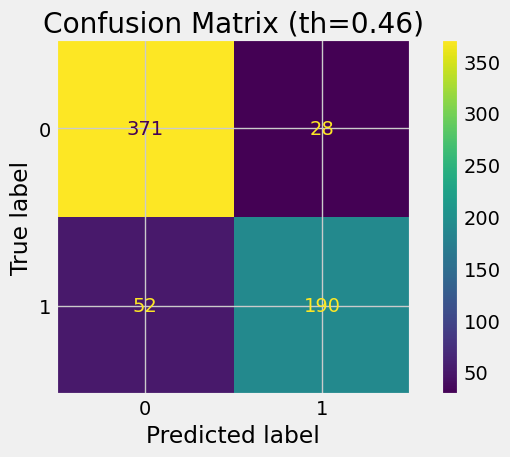

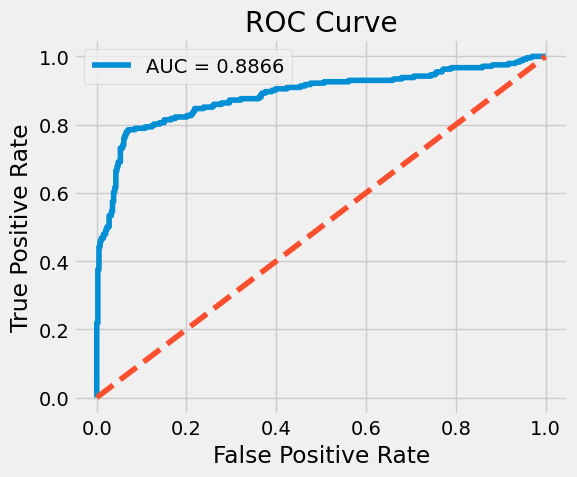


Best Threshold: 0.46
     model  best_threshold        f1  precision    recall  accuracy       auc  \
0  xgboost            0.46  0.826087    0.87156  0.785124  0.875195  0.886571   

   cv_f1_mean  cv_f1_std  cv_auc_mean  cv_auc_std  
0    0.833719   0.027014     0.889262    0.021079  


In [56]:
reset_seeds()

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight = 3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.0,
    reg_alpha=0.3,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_result = run_single_boosting_pipeline(
    model=xgb_model,
    model_name="xgboost",
    train_df=train,
    y=y_tr,
    test_df=ori_te,
    save_dir="results_xgboost_v1"
)

print("\nBest Threshold:", xgb_result["best_threshold"])
print(xgb_result["summary_df"])

# XGBoost 실험 후 바로 저장하는 코드

In [57]:
xgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8, #colsample_bytree = 0.8
    "gamma": 0.0,
    "reg_alpha": 0.3,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42
}

# 변경점
xgb_exp_id, experiment_log_df = save_experiment_log(
    model_name="xgboost",
    feature_version="subsample = 0.8",
    feature_count=15,
    result_obj=xgb_result,
    save_dir="results",
    public_score=None,
    notes="baseline boosting / subsample = 0.8",
    params=xgb_params
)

experiment_log_df.tail(3)

실험 로그 저장 완료: results/experiment_log.csv
exp_id: xgboost_subsample = 0.8_20260316_062739


,exp_id,timestamp,model,feature_version,feature_count,best_threshold,f1,precision,recall,accuracy,auc,cv_f1_mean,cv_f1_std,cv_auc_mean,cv_auc_std,public_score,notes,submission_path,params
2,xgboost_fe15_clean_20260316_062147,20260316_062147,xgboost,fe15_clean,15,0.54,0.817778,0.884615,0.760331,0.872075,0.885028,0.829355,0.024395,0.885997,0.020234,NaN,baseline boosting / min_child_weight = 3,results_xgboost_v1/xgboost_submission.csv,"{""n_estimators"": 500, ""learning_rate"": 0.03, ""..."
3,xgboost_colsample_bytree = 0.8_20260316_062523,20260316_062523,xgboost,colsample_bytree = 0.8,15,0.51,0.821192,0.881517,0.768595,0.873635,0.885758,0.828800,0.023423,0.887303,0.021884,NaN,baseline boosting / colsample_bytree = 0.8,results_xgboost_v1/xgboost_submission.csv,"{""n_estimators"": 500, ""learning_rate"": 0.03, ""..."
4,xgboost_subsample = 0.8_20260316_062739,20260316_062739,xgboost,subsample = 0.8,15,0.46,0.826087,0.871560,0.785124,0.875195,0.886571,0.833719,0.027014,0.889262,0.021079,None,baseline boosting / subsample = 0.8,results_xgboost_v1/xgboost_submission.csv,"{""n_estimators"": 500, ""learning_rate"": 0.03, ""..."


# public score 기준

In [ ]:
show_experiment_leaderboard(save_dir="results", sort_by="public_score", ascending=False)

,exp_id,model,feature_version,feature_count,best_threshold,f1,auc,cv_f1_mean,cv_auc_mean,public_score,notes
0,xgboost_f41_drop_ticket_group_20260316_013036,xgboost,f41_drop_ticket_group,41,0.59,0.812500,0.882382,0.822304,0.882301,NaN,baseline boosting / 41 features
1,xgboost_f40_drop_gender_20260316_013635,xgboost,f40_drop_gender,40,0.56,0.815145,0.883277,0.824213,0.883571,NaN,baseline boosting / 40 features
2,xgboost_f39_drop_pclass_is_male_20260316_014036,xgboost,f39_drop_pclass_is_male,39,0.57,0.814318,0.883728,0.823068,0.884063,NaN,baseline boosting / 39 features
3,xgboost_f38_drop_pclass_is_alone_20260316_014856,xgboost,f38_drop_pclass_is_alone,38,0.58,0.813333,0.882868,0.823692,0.883179,NaN,baseline boosting / 38 features
4,xgboost_xgboost_depth3_20260316_021307,xgboost,xgboost_depth3,37,0.61,0.816964,0.888155,0.828009,0.889281,NaN,baseline boosting / 37 features
5,xgboost_min_child_weight = 3_20260316_021623,xgboost,min_child_weight = 3,37,0.55,0.815145,0.889186,0.821751,0.891754,NaN,baseline boosting / min_child_weight = 3
6,xgboost_gamma = 0.1_20260316_021910,xgboost,gamma = 0.1,37,0.63,0.818792,0.888456,0.829225,0.889806,NaN,baseline boosting / gamma = 0.1
7,xgboost_max_depth=4_20260316_022328,xgboost,max_depth=4,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / max_depth=4
8,xgboost_max_depth=4_20260316_022348,xgboost,max_depth=4,37,0.59,0.813333,0.882216,0.824358,0.882041,NaN,baseline boosting / max_depth=4
9,xgboost_gamma=0.1_20260316_022551,xgboost,gamma=0.1,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / gamma=0.1


# CV F1 기준

In [ ]:
show_experiment_leaderboard(save_dir="results", sort_by="cv_f1_mean", ascending=False)

,exp_id,model,feature_version,feature_count,best_threshold,f1,auc,cv_f1_mean,cv_auc_mean,public_score,notes
0,xgboost_gamma = 0.1_20260316_021910,xgboost,gamma = 0.1,37,0.63,0.818792,0.888456,0.829225,0.889806,NaN,baseline boosting / gamma = 0.1
1,xgboost_xgboost_depth3_20260316_021307,xgboost,xgboost_depth3,37,0.61,0.816964,0.888155,0.828009,0.889281,NaN,baseline boosting / 37 features
2,xgboost_max_depth=4_20260316_022328,xgboost,max_depth=4,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / max_depth=4
3,xgboost_gamma=0.1_20260316_022551,xgboost,gamma=0.1,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / gamma=0.1
4,xgboost_gamma=0.1_20260316_022805,xgboost,gamma=0.1,37,0.56,0.811530,0.883728,0.825502,0.883231,NaN,baseline boosting / gamma=0.1
5,xgboost_subsample=0.8_20260316_023140,xgboost,subsample=0.8,37,0.59,0.815145,0.884256,0.825057,0.883438,NaN,baseline boosting / subsample=0.8
6,xgboost_max_depth=4_20260316_022348,xgboost,max_depth=4,37,0.59,0.813333,0.882216,0.824358,0.882041,NaN,baseline boosting / max_depth=4
7,xgboost_f40_drop_gender_20260316_013635,xgboost,f40_drop_gender,40,0.56,0.815145,0.883277,0.824213,0.883571,NaN,baseline boosting / 40 features
8,xgboost_f38_drop_pclass_is_alone_20260316_014856,xgboost,f38_drop_pclass_is_alone,38,0.58,0.813333,0.882868,0.823692,0.883179,NaN,baseline boosting / 38 features
9,xgboost_f39_drop_pclass_is_male_20260316_014036,xgboost,f39_drop_pclass_is_male,39,0.57,0.814318,0.883728,0.823068,0.884063,NaN,baseline boosting / 39 features


# AUC 기준

In [ ]:
show_experiment_leaderboard(save_dir="results", sort_by="cv_auc_mean", ascending=False)

,exp_id,model,feature_version,feature_count,best_threshold,f1,auc,cv_f1_mean,cv_auc_mean,public_score,notes
0,xgboost_min_child_weight = 3_20260316_021623,xgboost,min_child_weight = 3,37,0.55,0.815145,0.889186,0.821751,0.891754,NaN,baseline boosting / min_child_weight = 3
1,xgboost_gamma = 0.1_20260316_021910,xgboost,gamma = 0.1,37,0.63,0.818792,0.888456,0.829225,0.889806,NaN,baseline boosting / gamma = 0.1
2,xgboost_xgboost_depth3_20260316_021307,xgboost,xgboost_depth3,37,0.61,0.816964,0.888155,0.828009,0.889281,NaN,baseline boosting / 37 features
3,xgboost_gamma=0.1_20260316_022551,xgboost,gamma=0.1,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / gamma=0.1
4,xgboost_max_depth=4_20260316_022328,xgboost,max_depth=4,37,0.59,0.812500,0.883107,0.825898,0.884166,NaN,baseline boosting / max_depth=4
5,xgboost_f39_drop_pclass_is_male_20260316_014036,xgboost,f39_drop_pclass_is_male,39,0.57,0.814318,0.883728,0.823068,0.884063,NaN,baseline boosting / 39 features
6,xgboost_f40_drop_gender_20260316_013635,xgboost,f40_drop_gender,40,0.56,0.815145,0.883277,0.824213,0.883571,NaN,baseline boosting / 40 features
7,xgboost_subsample=0.8_20260316_023140,xgboost,subsample=0.8,37,0.59,0.815145,0.884256,0.825057,0.883438,NaN,baseline boosting / subsample=0.8
8,xgboost_gamma=0.1_20260316_022805,xgboost,gamma=0.1,37,0.56,0.811530,0.883728,0.825502,0.883231,NaN,baseline boosting / gamma=0.1
9,xgboost_f38_drop_pclass_is_alone_20260316_014856,xgboost,f38_drop_pclass_is_alone,38,0.58,0.813333,0.882868,0.823692,0.883179,NaN,baseline boosting / 38 features
